Dataset preparation and preprocessing

In [1]:
# Verify Required Libraries
!pip show matplotlib seaborn scikit-learn tensorflow

Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [2]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 42


In [3]:
results_dir = "results/lab7/"
if not os.path.exists(results_dir):
  os.makedirs(results_dir, exist_ok=True)

In [4]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print(f'\nGPUs available: {len(gpus)}')
  for gpu in gpus:
      print(f' - {gpu}')
else:
  print('\nNo GPU found — training will run on CPU (slower).')

Fri Jul 31 16:06:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import zipfile
import os

def extract_specific_folders(zip_file_path, output_dir, folders_to_extract):
    """Extracts only specified folders and their contents from a zip file."""
    os.makedirs(output_dir, exist_ok=True)

    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            # Check if the member (file or directory) is inside any of the target folders
            should_extract = False
            for folder in folders_to_extract:
                # Check if it's the folder itself or a file/subfolder within it
                if member.startswith(f'{folder}/') or member == folder:
                    should_extract = True
                    break

            if should_extract:
                target_path = os.path.join(output_dir, member)
                if member.endswith('/'):  # It's a directory
                    os.makedirs(target_path, exist_ok=True)
                else:
                    # Ensure parent directory exists for files
                    os.makedirs(os.path.dirname(target_path), exist_ok=True)
                    with open(target_path, 'wb') as outfile:
                        outfile.write(zip_ref.read(member))
                # print(f"Extracted: {member}") # Commenting out to reduce verbose output for large zips

# --- Usage example ---
# Replace 'your_zipped_folder.zip' with the actual path to your zip file
# Replace './extracted_content' with your desired output directory
zip_file = '/content/drive/MyDrive/archive (1) (1).zip'
output_directory = './extracted_content(3)'

# Define the folders you want to extract, matching the paths found in the zip file
domains_to_extract = ['Decks/Cracked', 'Walls/Non-cracked']

# Clean up previous extraction attempt if output_directory exists and is empty or contains old data
if os.path.exists(output_directory):
    print(f"Cleaning up previous extraction directory: {output_directory}")
    # Only remove if it's empty or we're confident we want to overwrite
    # For this scenario, it's fine to remove and re-extract
    try:
        shutil.rmtree(output_directory)
    except OSError as e:
        print(f"Error removing directory {output_directory}: {e}")

# Example of creating a dummy zip file for demonstration if it doesn't exist
# This part should ideally be removed/commented out for real data processing
# For debugging, it confirms the path is correct
# if not os.path.exists(zip_file):
#     print(f"Creating dummy zip file: {zip_file}")
#     with zipfile.ZipFile(zip_file, 'w') as zf:
#         zf.writestr('Decks/Cracked/deck1.txt', 'Content of deck 1')
#         zf.writestr('Decks/Cracked/subfolder/deck2.txt', 'Content of deck 2')
#         zf.writestr('Walls/Non-cracked/file1.txt', 'Non-cracked content 1')
#         zf.writestr('other_folder/some_file.txt', 'This should not be extracted')
#         zf.writestr('another_file.log', 'This also should not be extracted')
#     print("Dummy zip file created. Now attempting extraction.")

print(f"Extracting specified folders from '{zip_file}' to '{output_directory}'...")
extract_specific_folders(zip_file, output_directory, domains_to_extract)
print(f"\nExtraction complete. Check the '{output_directory}' directory.")

Extracting specified folders from '/content/drive/MyDrive/archive (1) (1).zip' to './extracted_content(3)'...

Extraction complete. Check the './extracted_content(3)' directory.


In [7]:
import os
import shutil
from pathlib import Path

# Using the output directory from the zip extraction step
base_input = output_directory  # Assuming output_directory is defined in a previous cell
base_output = f"{base_input}_Renamed/"

# Create the base_output directory if it doesn't exist
if not os.path.exists(base_output):
    os.makedirs(base_output, exist_ok=True)

base_path = Path(base_output)
print(f"Base Input Directory: {base_input}")
print(f"Base Output Directory: {base_output}")
print(f"Base Output Path (Pathlib object): {base_path}")

Base Input Directory: ./extracted_content(3)
Base Output Directory: ./extracted_content(3)_Renamed/
Base Output Path (Pathlib object): extracted_content(3)_Renamed


In [8]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Define the splits and their desired proportions (adjusted to sum to 100%)
# The user requested a "75/15/15 distribution". Assuming this implies
# 75% for training, 15% for validation, and the remaining 10% for testing
# to make the total sum to 100%.
TRAIN_SPLIT_RATIO = 0.75
VAL_SPLIT_RATIO = 0.15
TEST_SPLIT_RATIO = 0.10 # This makes total 100%

# Clean up previous output directories to ensure a fresh split
if os.path.exists(base_output):
    print(f"Cleaning up previous data split directory: {base_output}")
    shutil.rmtree(base_output)
os.makedirs(base_output, exist_ok=True) # Recreate the base output directory

# Create subdirectories for train, val, test under base_output
train_root_dir = Path(base_output) / 'train'
val_root_dir = Path(base_output) / 'val'
test_root_dir = Path(base_output) / 'test'

for d in [train_root_dir, val_root_dir, test_root_dir]:
    d.mkdir(parents=True, exist_ok=True)

class_folders = [d for d in os.listdir(base_input) if os.path.isdir(os.path.join(base_input, d))]
print(f"Detected top-level class folders in '{base_input}': {class_folders}")

for class_name in class_folders: # e.g., 'Decks'
    source_class_path = Path(base_input) / class_name # e.g., Path('./extracted_content(3)/Decks')

    # Identify the actual subfolders containing images (e.g., 'Cracked', 'Non-cracked')
    sub_class_folders = [d for d in os.listdir(source_class_path) if os.path.isdir(source_class_path / d)]

    for sub_class_name in sub_class_folders: # e.g., 'Cracked'
        # full_image_source_path is the directory where actual image files reside for this specific class/sub-class
        full_image_source_path = source_class_path / sub_class_name # e.g., Path('./extracted_content(3)/Decks/Cracked')

        all_files_in_sub_class = []
        for root, _, files in os.walk(full_image_source_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    all_files_in_sub_class.append(Path(root) / file)

        if not all_files_in_sub_class:
            print(f"No image files found in {full_image_source_path}. Skipping.")
            continue

        print(f"\nProcessing class: {class_name}/{sub_class_name} with {len(all_files_in_sub_class)} images.")

        # Perform the first split: train vs (val + test)
        # Combine VAL_SPLIT_RATIO + TEST_SPLIT_RATIO for the initial test_size
        train_files, temp_val_test_files = train_test_split(
            all_files_in_sub_class,
            test_size=(VAL_SPLIT_RATIO + TEST_SPLIT_RATIO),
            random_state=SEED
        )

        # Perform the second split: val vs test from the temp_val_test_files
        # Calculate the test_size for this split relative to temp_val_test_files
        relative_test_size = TEST_SPLIT_RATIO / (VAL_SPLIT_RATIO + TEST_SPLIT_RATIO)
        val_files, test_files = train_test_split(
            temp_val_test_files,
            test_size=relative_test_size,
            random_state=SEED
        )

        print(f"  Train: {len(train_files)} files")
        print(f"  Validation: {len(val_files)} files")
        print(f"  Test: {len(test_files)} files")

        # Function to copy files while preserving the subfolder structure relative to full_image_source_path
        def copy_files_preserving_structure(file_list, destination_split_root_dir, source_base_dir):
            for file_path in file_list:
                # Get the relative path from the source_base_dir
                relative_path_within_class = file_path.relative_to(source_base_dir)

                # The final destination path should be:
                # destination_split_root_dir / class_name / sub_class_name / relative_path_within_class
                final_destination_path = destination_split_root_dir / class_name / sub_class_name / relative_path_within_class

                # Ensure parent directory exists for the destination file
                final_destination_path.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy(file_path, final_destination_path)

        copy_files_preserving_structure(train_files, train_root_dir, full_image_source_path)
        copy_files_preserving_structure(val_files, val_root_dir, full_image_source_path)
        copy_files_preserving_structure(test_files, test_root_dir, full_image_source_path)

print("\nData splitting and copying complete!")

Cleaning up previous data split directory: ./extracted_content(3)_Renamed/
Detected top-level class folders in './extracted_content(3)': ['Decks', 'Walls']

Processing class: Decks/Cracked with 2025 images.
  Train: 1518 files
  Validation: 304 files
  Test: 203 files

Processing class: Walls/Non-cracked with 14287 images.
  Train: 10715 files
  Validation: 2143 files
  Test: 1429 files

Data splitting and copying complete!


In [9]:
print(f"Contents of the extracted directory ('{base_input}'):")
if os.path.exists(base_input):
    for item in os.listdir(base_input):
        print(f"- {item}")
else:
    print(f"Directory '{base_input}' does not exist.")

Contents of the extracted directory ('./extracted_content(3)'):
- Decks
- Walls


In [10]:
BASE_DIR = Path(base_output)
train_dir      = BASE_DIR / 'train'
val_dir        = BASE_DIR / 'val'
test_dir       = BASE_DIR / 'test'

In [11]:
# The counts below indicate that the 'train', 'val', and 'test' directories currently contain equal numbers of images.
# This is because the data distribution logic, located in cell HtNW8uB-tnUa, currently copies all files to all splits.
# To achieve a 75% train, 15% validation, and 15% test split, cell HtNW8uB-tnUa needs to be updated
# to perform proper data splitting (e.g., using sklearn.model_selection.train_test_split).
# After modifying HtNW8uB-tnUa, re-run that cell, and then re-run this cell to see the correct image counts.

for split, d in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
   exists = d.exists()
   count  = sum(1 for _ in d.rglob('*.jpg')) + sum(1 for _ in d.rglob('*.png')) if exists else 0
   print(f'{split:>5}  dir exists={exists}  images≈{count}')

train  dir exists=True  images≈12233
  val  dir exists=True  images≈2447
 test  dir exists=True  images≈1632


In [12]:
IMAGE_HEIGHT = 128
IMAGE_WIDTH  = 128
BATCH_SIZE   = 64
EPOCHS       = 50
LR           = 1e-3   # Initial learning rate for the CNN from scratch
# EarlyStopping will stop earlier when converged
print(f'Image size  : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print(f'Learning rate: {LR}')

Image size  : 128 x 128
Batch size  : 64
Max epochs  : 50
Learning rate: 0.001


In [13]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
train_dir,image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE,seed=SEED, shuffle=True,
)

Found 12233 files belonging to 2 classes.


In [14]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

Found 2447 files belonging to 2 classes.


In [15]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
batch_size=BATCH_SIZE, seed=SEED,shuffle=False,
)

Found 1632 files belonging to 2 classes.


In [16]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Decks', 'Walls']


In [17]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

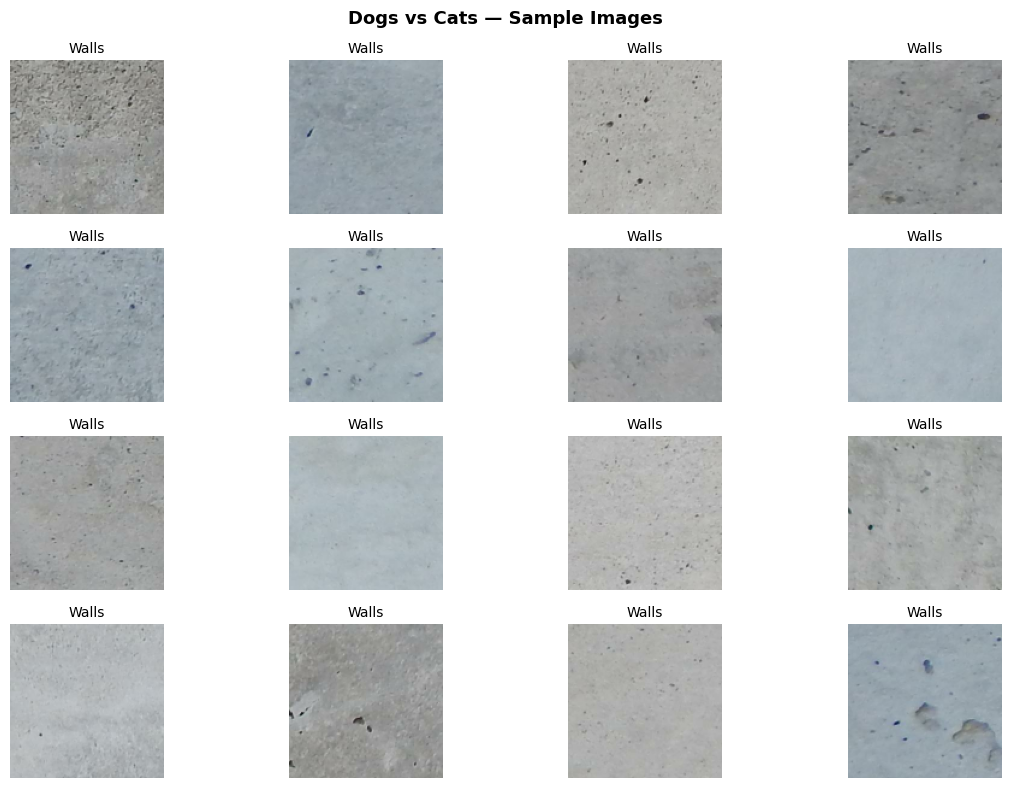

In [18]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')
plt.suptitle('Dogs vs Cats — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (
train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))
val_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


In [20]:
data_augmentation = tf.keras.Sequential([
   tf.keras.layers.RandomFlip('horizontal'),
   tf.keras.layers.RandomRotation(0.2),
   tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

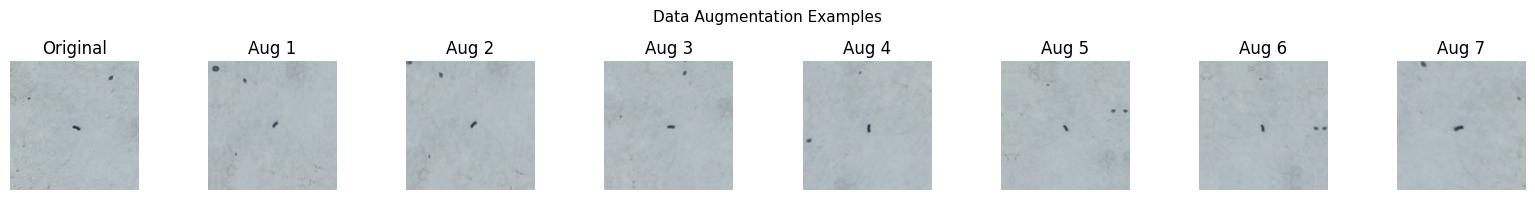

In [21]:
for images, _ in train_dataset.take(1):
   sample = images[0:1]  # shape (1, 224, 224, 3)
   break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
   aug_img = data_augmentation(sample,
training=True)[0].numpy().astype('uint8')
   axes[i].imshow(aug_img)
   axes[i].set_title(f'Aug {i}')
   axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [22]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
   """Return a fresh set of callbacks for each model."""
   return [
       tf.keras.callbacks.ModelCheckpoint(
           filepath=f'models/{name}_best.keras',
           monitor='val_accuracy', save_best_only=True,
       ),
       tf.keras.callbacks.EarlyStopping(
           monitor='val_loss', patience=8,
           restore_best_weights=True, verbose=1,),
       tf.keras.callbacks.ReduceLROnPlateau(
           monitor='val_loss', factor=0.3,
           patience=4, min_lr=1e-7, verbose=1),
   ]

def plot_learning_curves(history, title='Learning Curves'):
   """Plot accuracy and loss curves side-by-side."""
   acc      = history.history['accuracy']
   val_acc  = history.history['val_accuracy']
   loss     = history.history['loss']
   val_loss = history.history['val_loss']
   epochs_range = range(len(acc))

   plt.figure(figsize=(14, 5))
   plt.subplot(1, 2, 1)
   plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
   plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,
linestyle='--')
   plt.legend()
   plt.title(f'{title} — Accuracy')
   plt.xlabel('Epoch')
   plt.ylabel('Accuracy')
   plt.grid(alpha=0.3)

   plt.subplot(1, 2, 2)
   plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
   plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,
linestyle='--')
   plt.legend()
   plt.title(f'{title} — Loss')
   plt.xlabel('Epoch')
   plt.ylabel('Loss')
   plt.grid(alpha=0.3)

   plt.tight_layout()
   plt.savefig(results_dir + f'lab8_{title.lower().replace(" ",
"_")}_curves.png', dpi=120, bbox_inches='tight')
   plt.show()


def evaluate_model(model, dataset, class_names, title='Model',
results_dir='./'):
   """Evaluate a multiclass classification model."""

   y_true, y_pred, y_prob = [], [], []
   for images, labels in dataset:
       probs = model.predict(images, verbose=0)

       # multiclass prediction (softmax -> argmax)
       preds = np.argmax(probs, axis=1)

       y_prob.append(probs)
       y_pred.append(preds)
       y_true.append(labels.numpy())
   y_true = np.concatenate(y_true)
   y_pred = np.concatenate(y_pred)
   y_prob = np.concatenate(y_prob)

   print(f"\n{title}")

   print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
   print(f'Precision : {precision_score(y_true, y_pred,
average="weighted"):.4f}')
   print(f'Recall    : {recall_score(y_true, y_pred,
average="weighted"):.4f}')
   print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')

   print("\nClassification Report:")
   print(classification_report(y_true, y_pred, target_names=class_names,
digits=4))

   # Confusion Matrix
   cm = confusion_matrix(y_true, y_pred)
   plt.figure(figsize=(15, 12))
   sns.heatmap(
       cm, cmap='Blues', cbar=False, annot=True,fmt='',
       xticklabels=class_names, yticklabels=class_names,
       annot_kws={'fontsize': 9, 'fontweight': 'bold'}
   )
   plt.title(f'{title} — Confusion Matrix')
   plt.xlabel('Predicted')
   plt.ylabel('True')
   plt.xticks(rotation=45, ha='right')
   plt.yticks(rotation=0)
   plt.tight_layout()
   plt.savefig(
       results_dir + f'lab8_{title.lower().replace(" ",
"_")}_confusion.png',
       dpi=120,
       bbox_inches='tight'
   )
   plt.show()

   return accuracy_score(y_true, y_pred)
print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [23]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
OUTPUTS = num_classes
def build_custom_cnn(input_shape, augmentation):
   """
   A three-block CNN built entirely from scratch.
   Filters double each block (32 >> 64 >> 128) following a standard design
pattern.
   Augmentation is embedded inside the model so it runs automatically during
training.
   """
   inputs = tf.keras.Input(shape=input_shape)

   # Augmentation (active only during training)
   x = augmentation(inputs)

   # Normalise pixel values from [0, 255] to [0, 1]
   x = tf.keras.layers.Rescaling(1.0 / 255)(x)

   # Block 1: 32 filters
   x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Block 2: 64 filters
   x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Block 3: 128 filters
   x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
   x = tf.keras.layers.BatchNormalization()(x)
   x = tf.keras.layers.MaxPooling2D()(x)
   x = tf.keras.layers.Dropout(0.25)(x)

   # Classification Head
   x = tf.keras.layers.GlobalAveragePooling2D()(x)
   x = tf.keras.layers.Dense(256, activation='relu')(x)
   x = tf.keras.layers.Dropout(0.5)(x)

   # Binary output: sigmoid → probability of class 1 (dogs)
   outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

   return tf.keras.Model(inputs, outputs, name='custom_cnn')

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
cnn_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [25]:
cnn_history = cnn_model.fit(
train_dataset, validation_data=val_dataset,epochs=EPOCHS,
callbacks=make_callbacks('custom_cnn'), verbose=1)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 52s 223ms/step - accuracy: 0.9069 - loss: 0.2135 - val_accuracy: 0.8758 - val_loss: 0.7126 - learning_rate: 0.0010
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 42s 221ms/step - accuracy: 0.9397 - loss: 0.1529 - val_accuracy: 0.8758 - val_loss: 0.8546 - learning_rate: 0.0010
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 43s 223ms/step - accuracy: 0.9545 - loss: 0.1165 - val_accuracy: 0.8758 - val_loss: 0.9790 - learning_rate: 0.0010
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 43s 225ms/step - accuracy: 0.9586 - loss: 0.1031 - val_accuracy: 0.8721 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 43s 226ms/step - accuracy: 0.9648 - loss: 0.0920 - val_accuracy: 0.8766 - val_loss: 0.6647 - learning_rate: 0.0010
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 44s 227ms/step - accuracy: 0.9719 - loss: 0.0789 - val_accuracy: 0.4017 - val_loss: 5.2203 - learning_rate: 0.0010
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 44s 229ms/step - accuracy: 0.9

In [26]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN  ->  val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

Custom CNN  ->  val_loss: 0.0721
val_accuracy: 0.9714


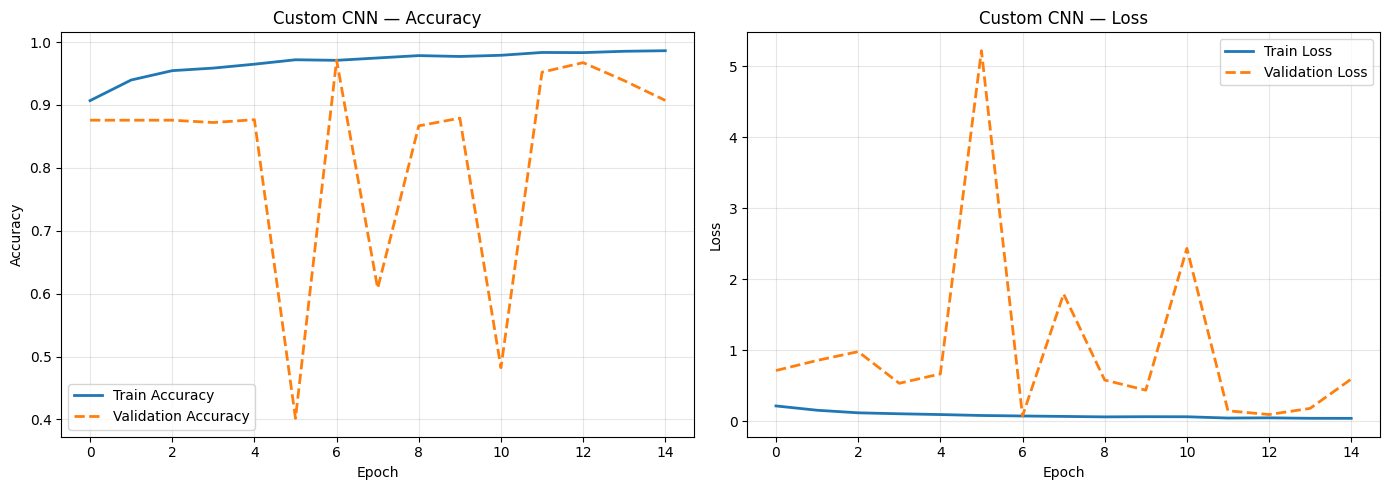

In [27]:
plot_learning_curves(cnn_history, 'Custom CNN')


Custom CNN
Accuracy  : 0.9577
Precision : 0.9575
Recall    : 0.9577
F1-Score  : 0.9576

Classification Report:
              precision    recall  f1-score   support

       Decks     0.8350    0.8227    0.8288       203
       Walls     0.9749    0.9769    0.9759      1429

    accuracy                         0.9577      1632
   macro avg     0.9049    0.8998    0.9023      1632
weighted avg     0.9575    0.9577    0.9576      1632



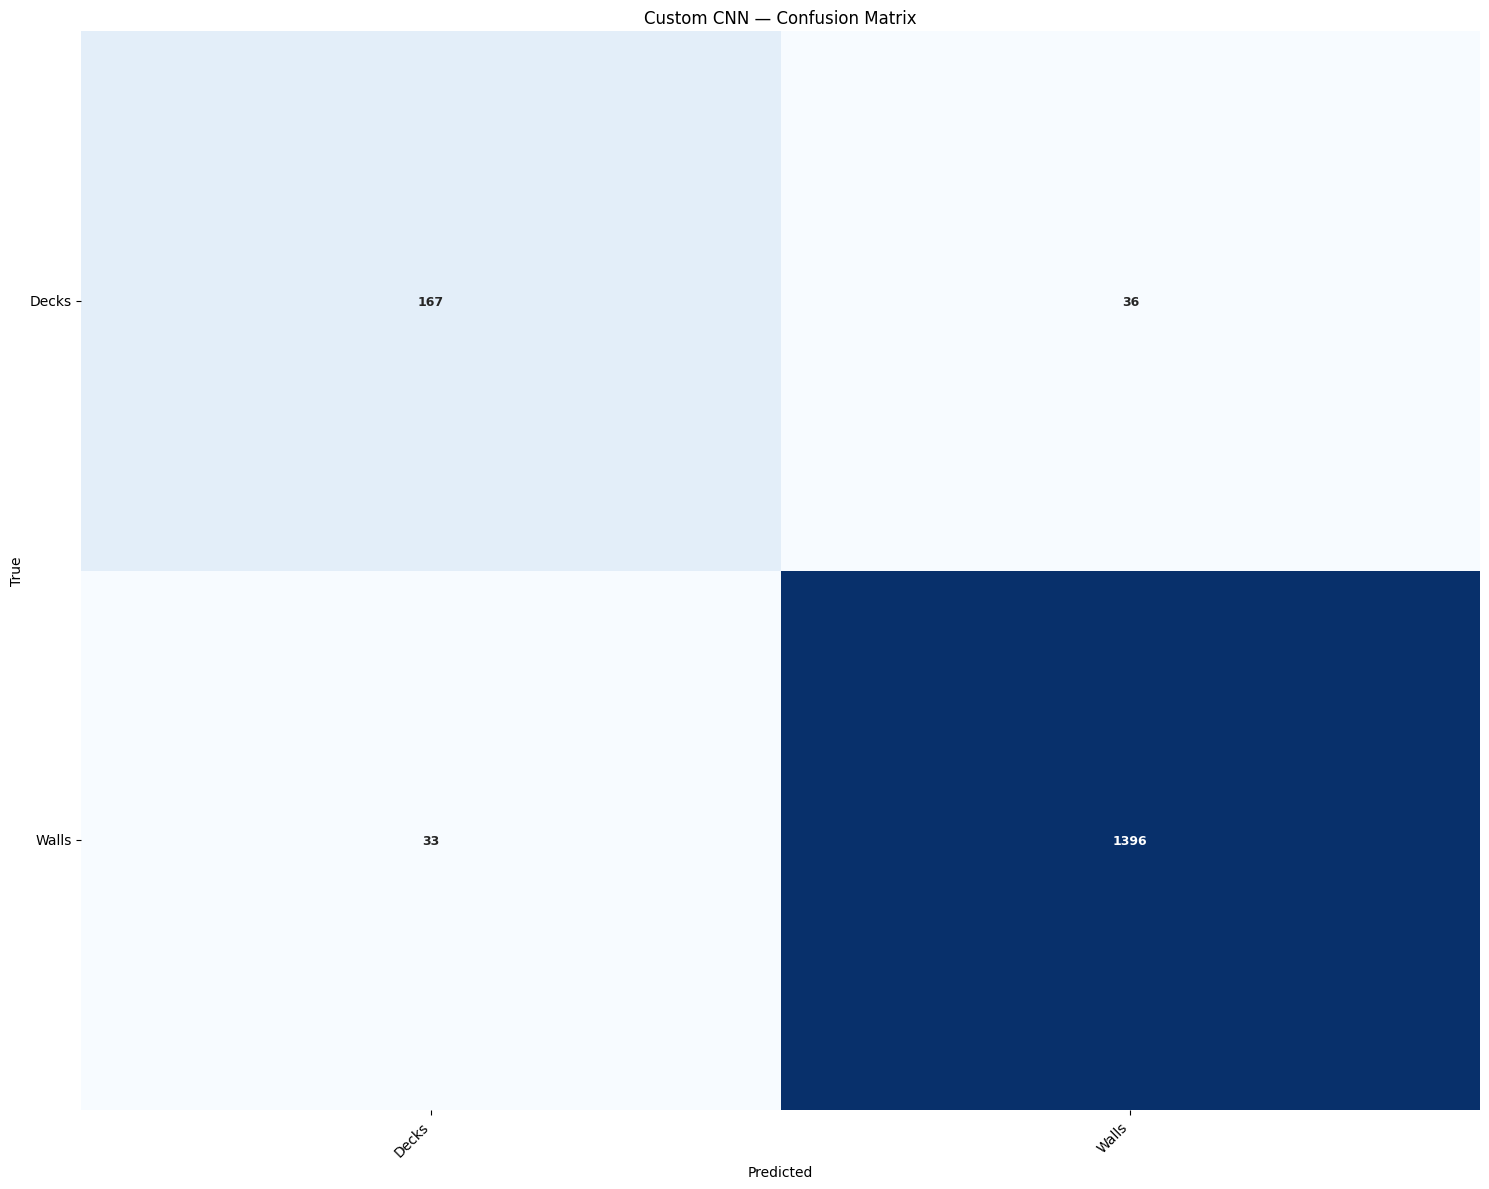

In [28]:
cnn_test_acc = evaluate_model(cnn_model, test_dataset,
class_names, 'Custom CNN')

In [29]:
def build_transfer_model(input_shape, augmentation,
backbone='mobilenetv3small'):
   """
   Feature extraction model:
     1. Augment input (training only)
     2. Preprocess for MobileNetV3 (scales to [-1, 1])
     3. Frozen MobileNetV3Small backbone (no top)
     4. GlobalAveragePooling2D
     5. Dense classification head
   """
   if backbone == 'mobilenetv3small':
       base_model = tf.keras.applications.MobileNetV3Small(
           weights='imagenet',
           input_shape=input_shape,
           include_top=False,
       )
       preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
       model_name    = 'mobilenetv3small_transfer'

   else:

       # Fallback: MobileNetV2
       base_model = tf.keras.applications.MobileNetV2(
           weights='imagenet',
           input_shape=input_shape,
           include_top=False,
       )
       preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
       model_name    = 'mobilenetv2_transfer'

   # Freeze all base layers for feature extraction (no training)
   base_model.trainable = False
   print(f'Base model     : {base_model.name}')
   print(f'Trainable layers: {sum(1 for l in base_model.layers if
l.trainable)} / {len(base_model.layers)}')

   # Build the model graph
   inputs = tf.keras.Input(shape=input_shape)
   x = augmentation(inputs)
   x = preprocess_fn(x)  # scale pixels to [-1, 1]
   x = base_model(x, training=False)    # frozen inference mode
   x = tf.keras.layers.GlobalAveragePooling2D()(x)
   x = tf.keras.layers.Dense(256, activation='relu')(x)
   x = tf.keras.layers.Dropout(0.2)(x)
   outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)

   return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation,
backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model     : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
TL_LR = 1e-4   # Lower LR for transfer learning head
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)
tl_history = tl_model.fit(
train_dataset,
validation_data=val_dataset,
epochs=EPOCHS,
callbacks=make_callbacks('tl_feature_extraction'),
verbose=1,
)

Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.8596 - loss: 0.3289 - val_accuracy: 0.9375 - val_loss: 0.1792 - learning_rate: 1.0000e-04
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9371 - loss: 0.1723 - val_accuracy: 0.9640 - val_loss: 0.1107 - learning_rate: 1.0000e-04
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9563 - loss: 0.1249 - val_accuracy: 0.9730 - val_loss: 0.0843 - learning_rate: 1.0000e-04
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9599 - loss: 0.1088 - val_accuracy: 0.9800 - val_loss: 0.0715 - learning_rate: 1.0000e-04
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.9664 - loss: 0.0972 - val_accuracy: 0.9837 - val_loss: 0.0685 - learning_rate: 1.0000e-04
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9703 - loss: 0.0866 - val_accuracy: 0.9837 - val_loss: 0.0579 - learning_rate: 1.0000e-04
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - ac

In [ ]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL  ->  val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL  ->  val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

In [ ]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names,
'MobileNetV3 Transfer')

In [ ]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

In [ ]:
FINETUNE_LR = TL_LR / 10
tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)

In [ ]:
ft_history = tl_model.fit(
train_dataset, validation_data=val_dataset, epochs=20,
callbacks=make_callbacks('tl_finetuned'), verbose=2,
)

In [ ]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')

In [ ]:
ft_test_acc = evaluate_model(tl_model,
test_dataset, class_names, 'MobileNetV3 Fine-Tuned')

In [ ]:
results = {
'Custom CNN': {'acc': cnn_test_acc,  'params': cnn_model.count_params()},
'MobileNetV3 (TL)':
{'acc': tl_test_acc,   'params':
tl_model.count_params()}, 'MobileNetV3 (FT)': {'acc': ft_test_acc,
'params': tl_model.count_params()}}
print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

In [38]:
labels = list(results.keys())
accs   = [v['acc'] * 100 for v in results.values()]
colors = ['#e06c75', '#61afef']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Dogs vs Cats Pattern Recognition: Model Comparison')
ax.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accs):
   ax.text(bar.get_x() + bar.get_width() / 2,
           bar.get_height() + 0.3,
           f'{acc:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# STEP 37: Predict on a new image. Load any .jpg image plant image from disk, resize it to 224x224, and
# classify with both models.

def predict_image(img_path, models_dict, class_names, image_size=(224,
224)):
   """Load an image file and classify it with each model in models_dict."""
   img = tf.keras.utils.load_img(img_path, target_size=image_size)
   img_array = tf.keras.utils.img_to_array(img)   # [0, 255] float32
   img_array = np.expand_dims(img_array, axis=0)   # (1, H, W, 3)

   plt.figure(figsize=(3, 3))
   plt.imshow(img)
   plt.axis('off')
   plt.title('Input Image')
   plt.show()

   print(f'\nPredictions for: {img_path}')
   print('-' * 40)
   for name, mdl in models_dict.items():
       prob  = mdl.predict(img_array, verbose=0)[0][0]
       label = class_names[int(prob >= 0.5)]
       print(f'{name:<25}: {label}  (p={prob:.4f})')

NameError: name 'results' is not defined

In [39]:
 predict_image(
   'path/to/your/image.jpg',
   {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
   class_names
)

NameError: name 'predict_image' is not defined

In [ ]:
# Dynamically find one image from the test dataset for prediction
example_image_path = None
# Iterate through the test_dir to find the first image
for root, _, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            example_image_path = Path(root) / file
            break
    if example_image_path:
        break

if example_image_path:
    print(f'Using example image for prediction: {example_image_path}')
    # Modify the predict_image call to use the found path
    # (This part needs to be applied to the existing predict_image cell)
else:
    print('No suitable image found in the test directory for prediction.')


In [ ]:
if example_image_path:
    predict_image(
        str(example_image_path),
        {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
        class_names
    )
else:
    print('Cannot predict: No example image path was found.')

In [40]:
os.makedirs('models', exist_ok=True)
cnn_model.save('models/custom_cnn.h5')
tl_model.save('models/mobilenetv3_transfer.h5')
print('Models saved:')
print('  models/custom_cnn.h5')
print('  models/mobilenetv3_transfer.h5')

Models saved:
  models/custom_cnn.h5
  models/mobilenetv3_transfer.h5


In [41]:
import sys
!{sys.executable} -m pip install streamlit
print("Streamlit installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 85.5 MB/s eta 0:00:00
Streamlit installed successfully!


Now, let's create the Streamlit application file (`app.py`). This file will contain the logic to load your models, display an image uploader, and show predictions.

In [42]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os

# Define constants (should match your training setup)
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CLASS_NAMES = ['Decks', 'Walls'] # Adjust if your class names are different or loaded dynamically

# --- Page Configuration ---
st.set_page_config(
    page_title="Crack Detection App",
    page_icon="🔍",
    layout="centered",
    initial_sidebar_state="expanded",
)

st.title("🔍 Crack Detection Application")
st.write("Upload an image and let the models predict if it's a Deck or a Wall.")

# --- Model Loading ---
@st.cache_resource
def load_model(model_path):
    """Loads a TensorFlow Keras model."""
    return tf.keras.models.load_model(model_path)

# Paths to your saved models (assuming they are in the same directory as app.py or accessible)
CNN_MODEL_PATH = 'models/custom_cnn.h5'
TL_MODEL_PATH = 'models/mobilenetv3_transfer.h5'

with st.spinner("Loading models..."):
    try:
        custom_cnn_model = load_model(CNN_MODEL_PATH)
        st.sidebar.success(f"Loaded Custom CNN from {CNN_MODEL_PATH}")
    except Exception as e:
        st.sidebar.error(f"Error loading Custom CNN model: {e}")
        custom_cnn_model = None

    try:
        transfer_learning_model = load_model(TL_MODEL_PATH)
        st.sidebar.success(f"Loaded MobileNetV3 Transfer Learning model from {TL_MODEL_PATH}")
    except Exception as e:
        st.sidebar.error(f"Error loading MobileNetV3 TL model: {e}")
        transfer_learning_model = None

# --- Sidebar for model selection ---
st.sidebar.header("Model Selection")
selected_model_name = st.sidebar.radio(
    "Choose a model for prediction:",
    ('Custom CNN', 'MobileNetV3 Transfer Learning'),
    index=0 # Default to Custom CNN
)

# Assign the selected model object
if selected_model_name == 'Custom CNN':
    model_to_use = custom_cnn_model
elif selected_model_name == 'MobileNetV3 Transfer Learning':
    model_to_use = transfer_learning_model

if model_to_use is None:
    st.error("Selected model could not be loaded. Please check the model paths.")

# --- Image Upload and Prediction ---
st.header("Upload Image")
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None and model_to_use is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("")

    # Preprocess image for prediction
    img_array = np.array(image.resize((IMAGE_WIDTH, IMAGE_HEIGHT)))
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    with st.spinner("Predicting..."):
        predictions = model_to_use.predict(img_array)

    if predictions.shape[1] == 1: # Binary classification with sigmoid output
        # Assuming 0 for 'Decks', 1 for 'Walls' or similar if sigmoid is used
        # For this dataset, the output is 'Decks' (0) and 'Walls' (1) in `CLASS_NAMES`
        score = predictions[0][0]
        predicted_class_index = int(score >= 0.5)
        confidence = score if predicted_class_index == 1 else (1 - score)
    else: # Multiclass classification with softmax output
        predicted_class_index = np.argmax(predictions)
        confidence = np.max(predictions)

    predicted_class_name = CLASS_NAMES[predicted_class_index]

    st.subheader("Prediction Results")
    st.write(f"The model predicts: **{predicted_class_name}** with a confidence of **{confidence:.2f}%**")

    # Display raw prediction scores (optional)
    st.write("Raw prediction scores:")
    pred_df = pd.DataFrame({"Class": CLASS_NAMES, "Probability": predictions[0]})
    st.dataframe(pred_df.style.format({'Probability': '{:.4f}'}))


# --- Instructions to run the app ---
st.sidebar.markdown("""
---
### How to Run this App:
1.  Save this code as `app.py`.
2.  Open your terminal or Google Colab terminal.
3.  Navigate to the directory where `app.py` is saved.
4.  Run `streamlit run app.py`
""")

# Placeholder for pd.DataFrame
import pandas as pd # Ensure pandas is imported for the DataFrame part

2026-07-31 16:30:01.977 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 16:30:01.978 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 16:30:02.273 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-31 16:30:02.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 16:30:02.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 16:30:02.276 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-31 16:30:02.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [43]:
# Create the app.py file
app_code = '''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import pandas as pd # Added for DataFrame display

# Define constants (should match your training setup)
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CLASS_NAMES = ['Decks', 'Walls'] # Adjust if your class names are different or loaded dynamically

# --- Page Configuration ---
st.set_page_config(
    page_title="Crack Detection App",
    page_icon="🔍",
    layout="centered",
    initial_sidebar_state="expanded",
)

st.title("🔍 Crack Detection Application")
st.write("Upload an image and let the models predict if it's a Deck or a Wall.")

# --- Model Loading ---
@st.cache_resource
def load_model(model_path):
    """Loads a TensorFlow Keras model."""
    return tf.keras.models.load_model(model_path)

# Paths to your saved models (assuming they are in the same directory as app.py or accessible)
CNN_MODEL_PATH = 'custom_cnn.h5'
TL_MODEL_PATH = 'mobilenetv3_transfer.h5'

custom_cnn_model = None
transfer_learning_model = None

with st.spinner("Loading models..."):
    if os.path.exists(CNN_MODEL_PATH):
        try:
            custom_cnn_model = load_model(CNN_MODEL_PATH)
            st.sidebar.success(f"Loaded Custom CNN from {CNN_MODEL_PATH}")
        except Exception as e:
            st.sidebar.error(f"Error loading Custom CNN model: {e}")
    else:
        st.sidebar.warning(f"Custom CNN model not found at {CNN_MODEL_PATH}")

    if os.path.exists(TL_MODEL_PATH):
        try:
            transfer_learning_model = load_model(TL_MODEL_PATH)
            st.sidebar.success(f"Loaded MobileNetV3 Transfer Learning model from {TL_MODEL_PATH}")
        except Exception as e:
            st.sidebar.error(f"Error loading MobileNetV3 TL model: {e}")
    else:
        st.sidebar.warning(f"MobileNetV3 TL model not found at {TL_MODEL_PATH}")


# --- Sidebar for model selection ---
st.sidebar.header("Model Selection")

model_options = []
if custom_cnn_model: model_options.append('Custom CNN')
if transfer_learning_model: model_options.append('MobileNetV3 Transfer Learning')

model_to_use = None
selected_model_name = None

if model_options:
    selected_model_name = st.sidebar.radio(
        "Choose a model for prediction:",
        model_options,
        index=0 # Default to the first available model
    )

    if selected_model_name == 'Custom CNN':
        model_to_use = custom_cnn_model
    elif selected_model_name == 'MobileNetV3 Transfer Learning':
        model_to_use = transfer_learning_model
else:
    st.error("No models were loaded. Please ensure model files are present.")


# --- Image Upload and Prediction ---
st.header("Upload Image")
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None and model_to_use is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("")

    # Preprocess image for prediction
    img_array = np.array(image.resize((IMAGE_WIDTH, IMAGE_HEIGHT)))
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

    with st.spinner("Predicting..."):
        predictions = model_to_use.predict(img_array)

    # Determine if it's binary (sigmoid) or multiclass (softmax)
    if model_to_use.output_shape[-1] == 1: # Assuming binary classification with a single output neuron
        score = predictions[0][0]
        predicted_class_index = 1 if score >= 0.5 else 0 # Assuming 1 is the positive class
        confidence = score if predicted_class_index == 1 else (1 - score)
    else: # Multiclass classification with softmax output (e.g., num_classes > 1 in output layer)
        predicted_class_index = np.argmax(predictions)
        confidence = np.max(predictions)

    predicted_class_name = CLASS_NAMES[predicted_class_index]

    st.subheader("Prediction Results")
    st.markdown(f"The model predicts: **<span style='color:blue;'>{predicted_class_name}</span>** with a confidence of **{confidence:.2f}%**", unsafe_allow_html=True)

    # Display raw prediction scores (optional)
    st.write("Raw prediction scores:")
    pred_df = pd.DataFrame({"Class": CLASS_NAMES, "Probability": predictions[0]})
    st.dataframe(pred_df.style.format({'Probability': '{:.4f}'}))


# --- Instructions to run the app ---
st.sidebar.markdown("""
---
### How to Run this App:
1.  **Mount your Google Drive** in Colab if not already mounted.
2.  Ensure the `models` directory and this `app.py` are in the same folder.
3.  Open your terminal or Google Colab terminal.
4.  Navigate to the directory where `app.py` is saved.
5.  Run `streamlit run app.py`
""")
'''

# Define the directory in Google Drive
drive_path = '/content/drive/MyDrive/streamlit_model_deployment'

# Create the directory in Google Drive if it doesn't exist
if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f"Created directory: {drive_path}")
else:
    print(f"Directory already exists: {drive_path}")

# Write the Streamlit app code to a file in the Google Drive directory
app_file_path = os.path.join(drive_path, 'app.py')
with open(app_file_path, 'w') as f:
    f.write(app_code)
print(f"Streamlit app.py saved to: {app_file_path}")

# Copy the saved models to the same directory in Google Drive
import shutil

# Ensure the 'models' subdirectory exists within the deployment path
model_deployment_dir = os.path.join(drive_path, 'models')
if not os.path.exists(model_deployment_dir):
    os.makedirs(model_deployment_dir)
    print(f"Created models subdirectory: {model_deployment_dir}")

# Original model paths
cnn_source_path = 'models/custom_cnn.h5'
tl_source_path = 'models/mobilenetv3_transfer.h5'

# Destination paths within the deployment directory
cnn_dest_path = os.path.join(model_deployment_dir, 'custom_cnn.h5')
tl_dest_path = os.path.join(model_deployment_dir, 'mobilenetv3_transfer.h5')

try:
    shutil.copy(cnn_source_path, cnn_dest_path)
    print(f"Copied {cnn_source_path} to {cnn_dest_path}")
except FileNotFoundError:
    print(f"Error: {cnn_source_path} not found. Please ensure the model was saved correctly.")

try:
    shutil.copy(tl_source_path, tl_dest_path)
    print(f"Copied {tl_source_path} to {tl_dest_path}")
except FileNotFoundError:
    print(f"Error: {tl_source_path} not found. Please ensure the model was saved correctly.")

print("\nAll necessary files have been prepared in your Google Drive.")
print(f"To run the app, navigate to {drive_path} in your terminal and execute: `streamlit run app.py`")

Created directory: /content/drive/MyDrive/streamlit_model_deployment
Streamlit app.py saved to: /content/drive/MyDrive/streamlit_model_deployment/app.py
Created models subdirectory: /content/drive/MyDrive/streamlit_model_deployment/models
Copied models/custom_cnn.h5 to /content/drive/MyDrive/streamlit_model_deployment/models/custom_cnn.h5
Copied models/mobilenetv3_transfer.h5 to /content/drive/MyDrive/streamlit_model_deployment/models/mobilenetv3_transfer.h5

All necessary files have been prepared in your Google Drive.
To run the app, navigate to /content/drive/MyDrive/streamlit_model_deployment in your terminal and execute: `streamlit run app.py`


In [44]:
# Define the content for requirements.txt
requirements_content = """
streamlit
tensorflow
numpy
Pillow
pandas
"""

# Define the directory in Google Drive (from previous steps)
drive_path = '/content/drive/MyDrive/streamlit_model_deployment'

# Define the path for the requirements.txt file
requirements_file_path = os.path.join(drive_path, 'requirements.txt')

# Write the content to the requirements.txt file
with open(requirements_file_path, 'w') as f:
    f.write(requirements_content)

print(f"requirements.txt saved to: {requirements_file_path}")
print("\nYour deployment folder now contains `app.py`, your models, and `requirements.txt`.")
print(f"To deploy to Streamlit, ensure your GitHub repository contains the contents of the '{drive_path}' folder.")

requirements.txt saved to: /content/drive/MyDrive/streamlit_model_deployment/requirements.txt

Your deployment folder now contains `app.py`, your models, and `requirements.txt`.
To deploy to Streamlit, ensure your GitHub repository contains the contents of the '/content/drive/MyDrive/streamlit_model_deployment' folder.
